# 1. Import Module


In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




Failed to find the pandas get_adjustment() function to patch
Failed to patch pandas - PandasTools will have limited functionality


# 2. Load data

In [2]:
file = "C:/Users/USER-PC/QSAR_Code/Skin Sensitization/dataset/skin_sensitization.sdf"

sdfInfo = dict(smilesName='SMILES',molColName='ROMol')
moldf = PandasTools.LoadSDF(file,**sdfInfo)
print(moldf.shape)
moldf = moldf.rename(columns={'ROMol': 'Mol'})
moldf = moldf[pd.notnull(moldf['Mol'])]
print(moldf.shape)
moldf.keys()

[13:02:44] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 7
[13:02:44] ERROR: Could not sanitize molecule ending on line 23569
[13:02:44] ERROR: Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 7
[13:02:44] Can't kekulize mol.  Unkekulized atoms: 6 7 8 10 11
[13:02:44] ERROR: Could not sanitize molecule ending on line 31194
[13:02:44] ERROR: Can't kekulize mol.  Unkekulized atoms: 6 7 8 10 11
[13:02:45] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[13:02:45] ERROR: Could not sanitize molecule ending on line 59708
[13:02:45] ERROR: Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[13:02:45] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 11
[13:02:45] ERROR: Could not sanitize molecule ending on line 68101
[13:02:45] ERROR: Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 11
[13:02:45] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[13:02:45] ERROR: Could not sanitize molecule ending on line 68783
[13:02:45] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 3 

(993, 8)
(993, 8)


Index(['Compound name', 'SMILES', 'CASRN', 'LLNA result', 'LLNA class',
       'LLNA reference', 'ID', 'Mol'],
      dtype='object')

In [3]:
moldf = moldf.rename(columns={'LLNA result': 'Outcome'})

In [4]:
moldf.head(1)

,Compound name,SMILES,CASRN,Outcome,LLNA class,LLNA reference,ID,Mol
0,"1,2-Benzisothiazolin-3-one",O=c1[nH]sc2ccccc12,2634-33-5,1,Moderate,ICCVAM (2013),,<rdkit.Chem.rdchem.Mol object at 0x0000021484D...


In [5]:
moldf= moldf.sort_values(['Outcome'], ascending=True)
moldf['RowID'] = moldf.index
moldf.head(100)

,Compound name,SMILES,CASRN,Outcome,LLNA class,LLNA reference,ID,Mol,RowID
999,?-Terpinene,C=C1CC=C(C(C)C)CC1,99-84-3,0,Non-sensitizer,ICCVAM (2013),,<rdkit.Chem.rdchem.Mol object at 0x0000021485E...,999
680,2-(4-methyl-2-nitrophenyl)diazenyl-3-oxo-N-phe...,CC(=O)/C(=N\Nc1ccc(C)cc1[N+](=O)[O-])C(=O)Nc1c...,2512-29-0,0,,REACH (2008-2014),,<rdkit.Chem.rdchem.Mol object at 0x0000021485E...,680
681,"2-(4-nitrophenyl)diazenyl-3-oxo-N-(2-oxo-1,3-d...",CC(=O)/C(=N\Nc1ccc([N+](=O)[O-])cc1)C(=O)Nc1cc...,52846-56-7,0,,REACH (2008-2014),,<rdkit.Chem.rdchem.Mol object at 0x0000021485E...,681
682,"2-(benzyl)tert-butyl)amino)-1-(?,4-dihydroxy-m...",CC(C)(C)N(Cc1ccccc1)CC(O)c1ccc(O)c(CO)c1,24085-03-8,0,Non-sensitizer,ICCVAM (2013),,<rdkit.Chem.rdchem.Mol object at 0x0000021485E...,682
683,"2-(chloromethyl)oxirane; 2,6-dibromo-4-[2-(3,5...",CC(C)(c1cc(Br)c(O)c(Br)c1)c1cc(Br)c(O)c(Br)c1,40039-93-8,0,,REACH (2008-2014),,<rdkit.Chem.rdchem.Mol object at 0x0000021485E...,683
...,...,...,...,...,...,...,...,...,...
744,"2-{2-[3,3'-dichloro-4'-(2-{1-[(2,4-dimethylphe...",COc1ccccc1NC(=O)/C(=N/Nc1ccc(-c2ccc(N/N=C(\C(C...,68610-86-6,0,,REACH (2008-2014),,<rdkit.Chem.rdchem.Mol object at 0x0000021484E...,744
742,2-propan-2-yloxypropane,CC(C)OC(C)C,108-20-3,0,,REACH (2008-2014),,<rdkit.Chem.rdchem.Mol object at 0x0000021485E...,742
712,"2-[2-[2-[2-[1,3-dioxo-1-[(2-oxo-1,3-dihydroben...",CC(=O)/C(=N/Nc1ccccc1OCCOc1ccccc1N/N=C(\C(C)=O...,77804-81-0,0,,REACH (2008-2014),,<rdkit.Chem.rdchem.Mol object at 0x0000021485E...,712
713,"2-[2-chloro-4-[3-chloro-4-[1,3-dioxo-1-(phenyl...",CC(=O)/C(=N\Nc1ccc(-c2ccc(N/N=C(\C(C)=O)C(=O)N...,6358-85-6,0,,REACH (2008-2014),,<rdkit.Chem.rdchem.Mol object at 0x0000021485E...,713


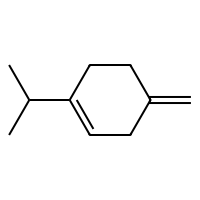

C=C1CC=C(C(C)C)CC1


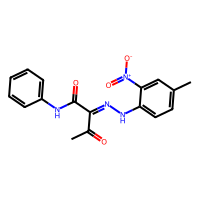

CC(=O)/C(=N\Nc1ccc(C)cc1[N+](=O)[O-])C(=O)Nc1ccccc1


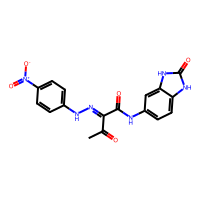

CC(=O)/C(=N\Nc1ccc([N+](=O)[O-])cc1)C(=O)Nc1ccc2[nH]c(=O)[nH]c2c1


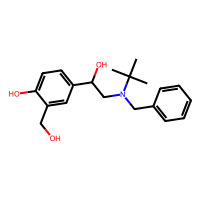

CC(C)(C)N(Cc1ccccc1)CC(O)c1ccc(O)c(CO)c1


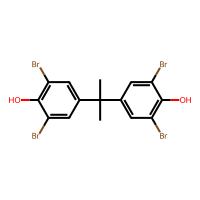

CC(C)(c1cc(Br)c(O)c(Br)c1)c1cc(Br)c(O)c(Br)c1


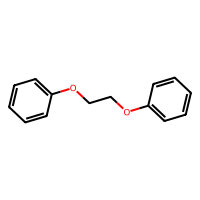

c1ccc(OCCOc2ccccc2)cc1


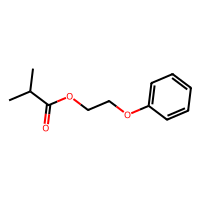

CC(C)C(=O)OCCOc1ccccc1


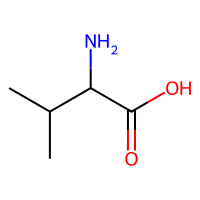

CC(C)C(N)C(=O)O


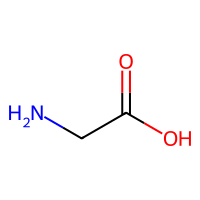

NCC(=O)O


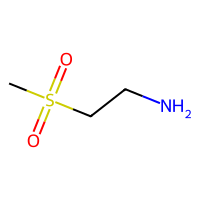

CS(=O)(=O)CCN


In [6]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def display_molecules_in_column(moldf, num_mols):
    for _, row in moldf.head(num_mols).iterrows():
        smi = row['SMILES']
        if smi is not None:
            mol = Chem.MolFromSmiles(smi)  # Create Mol object from SMILES
            if mol is not None:
                img = Draw.MolToImage(mol, size=(200, 200))
                display(img)
                print(smi)  # Prints the SMILES representation below the image

# Assuming 'df' is your DataFrame
# Display the first 10 molecules, each on a new row
display_molecules_in_column(moldf, 10)


In [7]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from mordred import Calculator, descriptors
from fancyimpute import KNN


(CVXPY) Sep 19 01:03:16 PM: Encountered unexpected exception importing solver CVXOPT:
ImportError('DLL load failed while importing base: The specified module could not be found.')
(CVXPY) Sep 19 01:03:16 PM: Encountered unexpected exception importing solver GLPK:
ImportError('DLL load failed while importing base: The specified module could not be found.')
(CVXPY) Sep 19 01:03:16 PM: Encountered unexpected exception importing solver GLPK_MI:
ImportError('DLL load failed while importing base: The specified module could not be found.')


## 3. Morgan, MACCsKeys, Modred

In [9]:
# Morgan fingerprints
nBits = 1024
radius = 2
useFeatures = False
moldf['Morgan_Descriptors'] = moldf['Mol'].apply(lambda mol: AllChem.GetMorganFingerprintAsBitVect(mol, nBits=nBits, radius=radius, useFeatures=useFeatures))

# MACCS keys
moldf['MACCS_Descriptors'] = moldf['Mol'].apply(lambda mol: MACCSkeys.GenMACCSKeys(mol))



In [10]:
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from mordred import Calculator, descriptors

# create descriptor calculator with all descriptors
calc = Calculator(descriptors, ignore_3D=True)
df = calc.pandas(moldf['Mol'])

  2%|▏         | 23/993 [00:04<01:52,  8.60it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  7%|▋         | 72/993 [00:04<00:31, 29.11it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 13%|█▎        | 131/993 [00:05<00:15, 55.30it/s]

...

 41%|████▏     | 411/993 [00:08<00:08, 72.09it/s] [14:56:10] WARNING: not removing hydrogen atom without neighbors
[14:56:10] WARNING: not removing hydrogen atom without neighbors
[14:56:10] WARNING: not removing hydrogen atom without neighbors
[14:56:10] WARNING: not removing hydrogen atom without neighbors
[14:56:10] WARNING: not removing hydrogen atom without neighbors
[14:56:10] WARNING: not removing hydrogen atom without neighbors
 82%|████████▏ | 817/993 [00:14<00:03, 47.50it/s] 

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 91%|█████████ | 900/993 [00:15<00:01, 73.67it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 993/993 [00:16<00:00, 59.35it/s]


In [11]:
from fancyimpute import KNN
import pandas as pd
import numpy as np

df_numeric = df.select_dtypes(include=[float]) 

df_filled = pd.DataFrame(KNN(k=3).fit_transform(df_numeric), columns=df_numeric.columns, index=df_numeric.index)


Imputing row 1/993 with 0 missing, elapsed time: 0.985
Imputing row 101/993 with 0 missing, elapsed time: 0.986
Imputing row 201/993 with 0 missing, elapsed time: 0.986
Imputing row 301/993 with 0 missing, elapsed time: 0.987
Imputing row 401/993 with 0 missing, elapsed time: 0.987
Imputing row 501/993 with 0 missing, elapsed time: 0.987
Imputing row 601/993 with 0 missing, elapsed time: 0.988
Imputing row 701/993 with 0 missing, elapsed time: 0.988
Imputing row 801/993 with 0 missing, elapsed time: 0.989
Imputing row 901/993 with 0 missing, elapsed time: 0.989


In [12]:
X = np.array(df_filled)
scaler = StandardScaler()
x=  scaler.fit_transform(X)
moldf['Modred_Descriptor'] = x.tolist()

In [13]:
print(x.shape)

(993, 545)


In [14]:
moldf

,Compound name,SMILES,CASRN,Outcome,LLNA class,LLNA reference,ID,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
999,?-Terpinene,C=C1CC=C(C(C)C)CC1,99-84-3,0,Non-sensitizer,ICCVAM (2013),,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAC...,999,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8826092981170142, -0.7466351232849535, -0...."
680,2-(4-methyl-2-nitrophenyl)diazenyl-3-oxo-N-phe...,CC(=O)/C(=N\Nc1ccc(C)cc1[N+](=O)[O-])C(=O)Nc1c...,2512-29-0,0,,REACH (2008-2014),,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAB...,680,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0465874648687186, 1.031234528436217, 0.8511..."
681,"2-(4-nitrophenyl)diazenyl-3-oxo-N-(2-oxo-1,3-d...",CC(=O)/C(=N\Nc1ccc([N+](=O)[O-])cc1)C(=O)Nc1cc...,52846-56-7,0,,REACH (2008-2014),,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAB...,681,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.545517662192615, 1.5558518027145951, 1.3733..."
682,"2-(benzyl)tert-butyl)amino)-1-(?,4-dihydroxy-m...",CC(C)(C)N(Cc1ccccc1)CC(O)c1ccc(O)c(CO)c1,24085-03-8,0,Non-sensitizer,ICCVAM (2013),,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAB...,682,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.270473824587102, 0.3725483951755866, 0.2128..."
683,"2-(chloromethyl)oxirane; 2,6-dibromo-4-[2-(3,5...",CC(C)(c1cc(Br)c(O)c(Br)c1)c1cc(Br)c(O)c(Br)c1,40039-93-8,0,,REACH (2008-2014),,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAB...,683,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.028042873654533625, 0.25683034619895667, 0...."
...,...,...,...,...,...,...,...,...,...,...,...,...
360,5-Ethyl-2-methylpyridine,CCc1ccc(C)nc1,104-90-5,1,,REACH (2008-2014),,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,360,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7606485832156172, -0.6183953451280166, -0...."
361,"5-Methoxy-6-(trifluoromethyl)-2,3-dihydro-1H-i...",COc1cc2c(cc1C(F)(F)F)NCC2,178896-79-2,1,Weak,ICCVAM (2013),,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,361,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.43678389036173415, 0.2676249403199109, 0.60..."
362,5-Methyleugenol,C=CCc1cc(OC)c(O)cc1C,186743-25-9,1,Weak,ICCVAM (2013),,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,362,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3615044253565001, -0.2686504956090979, -0...."
350,"4-[1,3-bis(5-tert-butyl-4-hydroxy-2-methylphen...",Cc1cc(O)c(C(C)(C)C)cc1C(C)CC(c1cc(C(C)(C)C)c(O...,1843-03-4,1,,REACH (2008-2014),,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,350,"[0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9800634385588658, 1.4392701862082888, 1.191..."


In [15]:
moldf.keys()

Index(['Compound name', 'SMILES', 'CASRN', 'Outcome', 'LLNA class',
       'LLNA reference', 'ID', 'Mol', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor'],
      dtype='object')

In [16]:
data = moldf.drop(columns=['CASRN', 'LLNA reference', 'ID'])

In [17]:
data

,Compound name,SMILES,Outcome,LLNA class,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
999,?-Terpinene,C=C1CC=C(C(C)C)CC1,0,Non-sensitizer,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAC...,999,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8826092981170142, -0.7466351232849535, -0...."
680,2-(4-methyl-2-nitrophenyl)diazenyl-3-oxo-N-phe...,CC(=O)/C(=N\Nc1ccc(C)cc1[N+](=O)[O-])C(=O)Nc1c...,0,,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAB...,680,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0465874648687186, 1.031234528436217, 0.8511..."
681,"2-(4-nitrophenyl)diazenyl-3-oxo-N-(2-oxo-1,3-d...",CC(=O)/C(=N\Nc1ccc([N+](=O)[O-])cc1)C(=O)Nc1cc...,0,,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAB...,681,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.545517662192615, 1.5558518027145951, 1.3733..."
682,"2-(benzyl)tert-butyl)amino)-1-(?,4-dihydroxy-m...",CC(C)(C)N(Cc1ccccc1)CC(O)c1ccc(O)c(CO)c1,0,Non-sensitizer,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAB...,682,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.270473824587102, 0.3725483951755866, 0.2128..."
683,"2-(chloromethyl)oxirane; 2,6-dibromo-4-[2-(3,5...",CC(C)(c1cc(Br)c(O)c(Br)c1)c1cc(Br)c(O)c(Br)c1,0,,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAB...,683,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.028042873654533625, 0.25683034619895667, 0...."
...,...,...,...,...,...,...,...,...,...
360,5-Ethyl-2-methylpyridine,CCc1ccc(C)nc1,1,,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,360,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7606485832156172, -0.6183953451280166, -0...."
361,"5-Methoxy-6-(trifluoromethyl)-2,3-dihydro-1H-i...",COc1cc2c(cc1C(F)(F)F)NCC2,1,Weak,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,361,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.43678389036173415, 0.2676249403199109, 0.60..."
362,5-Methyleugenol,C=CCc1cc(OC)c(O)cc1C,1,Weak,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,362,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3615044253565001, -0.2686504956090979, -0...."
350,"4-[1,3-bis(5-tert-butyl-4-hydroxy-2-methylphen...",Cc1cc(O)c(C(C)(C)C)cc1C(C)CC(c1cc(C(C)(C)C)c(O...,1,,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,350,"[0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9800634385588658, 1.4392701862082888, 1.191..."


In [18]:
data.keys()

Index(['Compound name', 'SMILES', 'Outcome', 'LLNA class', 'Mol', 'RowID',
       'Morgan_Descriptors', 'MACCS_Descriptors', 'Modred_Descriptor'],
      dtype='object')

# 4. Split into Train and Test Data and Save into sdf file

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect



# Remove duplicate columns
data = data.loc[:, ~data.columns.duplicated()]

# Split the data into train and test sets
train, test = train_test_split(data, test_size=0.2, random_state=42)

# Function to convert bit vectors to a list of integers
def bitvector_to_list(bitvector):
    if isinstance(bitvector, ExplicitBitVect):
        return list(map(int, bitvector.ToBitString()))
    else:
        return bitvector

# Convert bit vectors to lists before saving
def convert_bit_vectors(df):
    if 'Morgan_Descriptors' in df.columns:
        df['Morgan_Descriptors'] = df['Morgan_Descriptors'].apply(bitvector_to_list)
    if 'MACCS_Descriptors' in df.columns:
        df['MACCS_Descriptors'] = df['MACCS_Descriptors'].apply(bitvector_to_list)
    return df

# Convert bit vectors for train and test sets
train = convert_bit_vectors(train)
test = convert_bit_vectors(test)

# Function to save DataFrame to SDF
def save_to_sdf(df, filename):
    sdf_writer = Chem.SDWriter(filename)
    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row['SMILES'])
        if mol is not None:
            mol.SetProp("_Name", str(idx))
            for col in df.columns:
                if col != 'Mol' and col != 'SMILES':
                    mol.SetProp(col, str(row[col]))
            sdf_writer.write(mol)
    sdf_writer.close()


# Save the train and test sets to SDF files
save_to_sdf(train, 'C:/Users/USER-PC/QSAR_Code/Skin Sensitization/dataset/train_set_skin_sensitization_features.sdf')
save_to_sdf(test, 'C:/Users/USER-PC/QSAR_Code/Skin Sensitization/dataset/test_set_skin_sensitization_features.sdf')

print("Train and test sets saved to 'train_set.sdf' and 'test_set.sdf' respectively.")


[14:58:00] WARNING: not removing hydrogen atom without neighbors
[14:58:00] WARNING: not removing hydrogen atom without neighbors
[14:58:00] WARNING: not removing hydrogen atom without neighbors


Train and test sets saved to 'train_set.sdf' and 'test_set.sdf' respectively.


In [20]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df('C:/Users/USER-PC/QSAR_Code/Skin Sensitization/dataset/train_set_skin_sensitization_features.sdf')
test_df = load_sdf_to_df('C:/Users/USER-PC/QSAR_Code/Skin Sensitization/dataset/test_set_skin_sensitization_features.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())

print("Test DataFrame:")
print(test_df.head())


[14:58:02] WARNING: not removing hydrogen atom without neighbors
[14:58:02] WARNING: not removing hydrogen atom without neighbors
[14:58:02] WARNING: not removing hydrogen atom without neighbors
[14:58:02] WARNING: not removing hydrogen atom without neighbors
[14:58:02] WARNING: not removing hydrogen atom without neighbors
[14:58:02] WARNING: not removing hydrogen atom without neighbors


Train DataFrame:
                                       Compound name Outcome LLNA class RowID  \
0               2-Methyl-5-nitrobenzenesulfonic acid       1              278   
1  2-{4-chloro-3-[(4-ethoxyphenyl)methyl]phenyl}-...       1              295   
2                                            Eugenol       1       Weak    56   
3      3-Aminomethyl-3,5,5- trimethylcyclohexylamine       1     Strong   309   
4                                 2-Methylresorcinol       1              280   

                                  Morgan_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [21]:
train_df

,Compound name,Outcome,LLNA class,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES
0,2-Methyl-5-nitrobenzenesulfonic acid,1,,278,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.2618503396950841, -0.2395050914825213, 0.29...",Cc1ccc([N+](=O)[O-])cc1S(=O)(=O)O
1,2-{4-chloro-3-[(4-ethoxyphenyl)methyl]phenyl}-...,1,,295,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.05548471118588, 1.0726857698606813, 1.08843...",CCOc1ccc(Cc2cc(C3(OC)OC(CO)C(O)C(O)C3O)ccc2Cl)cc1
2,Eugenol,1,Weak,56,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.40585377622973534, -0.3327703846875663, -0...",C=CCc1ccc(O)c(OC)c1
3,"3-Aminomethyl-3,5,5- trimethylcyclohexylamine",1,Strong,309,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8271726095254701, -0.7058315575077464, -0....",CC1(C)CC(N)CC(C)(CN)C1
4,2-Methylresorcinol,1,,280,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5610765042860587, -0.47849740532044915, -0...",Cc1c(O)cccc1O
...,...,...,...,...,...,...,...,...
789,"2-[3,3-bis(3-tert-butyl-4-hydroxyphenyl)butano...",0,,721,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.6320767585868783, 2.9839766049168466, 2.508...",CC(C)(C)c1cc(C(C)(CC(=O)OCCOC(=O)CC(C)(c2ccc(O...
790,Pigment Violet 29,0,,930,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5344303244743063, 2.0280073495651356, 2.218...",O=C1NC(=O)c2ccc3c4ccc5c6c(ccc(c7ccc1c2c73)c64)...
791,"[(1R,4aR,4bS,10aR)-1,4a-dimethyl-7-propan-2-yl...",1,,473,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4723778025395882, -0.2686504956090979, -0....",CC(C)C1CCC2C(CCC3C(C)(CO)CCCC23C)C1
792,"4-fluoro-4-methyl-2-[(2,2,2-trifluoro-1-{4'-me...",0,,795,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.8140776202583173, 1.1497591718842952, 1.540...",CC(C)(F)CC(NC(c1ccc(-c2ccc(S(C)(=O)=O)cc2)cc1)...


In [22]:
train

,Compound name,SMILES,Outcome,LLNA class,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
278,2-Methyl-5-nitrobenzenesulfonic acid,Cc1ccc([N+](=O)[O-])cc1S(=O)(=O)O,1,,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,278,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.2618503396950841, -0.2395050914825213, 0.29..."
295,2-{4-chloro-3-[(4-ethoxyphenyl)methyl]phenyl}-...,CCOc1ccc(Cc2cc(C3(OC)OC(CO)C(O)C(O)C3O)ccc2Cl)cc1,1,,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,295,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.05548471118588, 1.0726857698606813, 1.08843..."
56,Eugenol,C=CCc1ccc(O)c(OC)c1,1,Weak,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,56,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.40585377622973534, -0.3327703846875663, -0..."
309,"3-Aminomethyl-3,5,5- trimethylcyclohexylamine",CC1(C)CC(N)CC(C)(CN)C1,1,Strong,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,309,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8271726095254701, -0.7058315575077464, -0...."
280,2-Methylresorcinol,Cc1c(O)cccc1O,1,,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,280,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5610765042860587, -0.47849740532044915, -0..."
...,...,...,...,...,...,...,...,...,...
721,"2-[3,3-bis(3-tert-butyl-4-hydroxyphenyl)butano...",CC(C)(C)c1cc(C(C)(CC(=O)OCCOC(=O)CC(C)(c2ccc(O...,0,,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAB...,721,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.6320767585868783, 2.9839766049168466, 2.508..."
930,Pigment Violet 29,O=C1NC(=O)c2ccc3c4ccc5c6c(ccc(c7ccc1c2c73)c64)...,0,,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAC...,930,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5344303244743063, 2.0280073495651356, 2.218..."
473,"[(1R,4aR,4bS,10aR)-1,4a-dimethyl-7-propan-2-yl...",CC(C)C1CCC2C(CCC3C(C)(CO)CCCC23C)C1,1,,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,473,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4723778025395882, -0.2686504956090979, -0...."
795,"4-fluoro-4-methyl-2-[(2,2,2-trifluoro-1-{4'-me...",CC(C)(F)CC(NC(c1ccc(-c2ccc(S(C)(=O)=O)cc2)cc1)...,0,,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAC...,795,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.8140776202583173, 1.1497591718842952, 1.540..."


In [23]:
train

,Compound name,SMILES,Outcome,LLNA class,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
278,2-Methyl-5-nitrobenzenesulfonic acid,Cc1ccc([N+](=O)[O-])cc1S(=O)(=O)O,1,,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,278,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.2618503396950841, -0.2395050914825213, 0.29..."
295,2-{4-chloro-3-[(4-ethoxyphenyl)methyl]phenyl}-...,CCOc1ccc(Cc2cc(C3(OC)OC(CO)C(O)C(O)C3O)ccc2Cl)cc1,1,,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,295,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.05548471118588, 1.0726857698606813, 1.08843..."
56,Eugenol,C=CCc1ccc(O)c(OC)c1,1,Weak,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,56,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.40585377622973534, -0.3327703846875663, -0..."
309,"3-Aminomethyl-3,5,5- trimethylcyclohexylamine",CC1(C)CC(N)CC(C)(CN)C1,1,Strong,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,309,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8271726095254701, -0.7058315575077464, -0...."
280,2-Methylresorcinol,Cc1c(O)cccc1O,1,,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,280,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5610765042860587, -0.47849740532044915, -0..."
...,...,...,...,...,...,...,...,...,...
721,"2-[3,3-bis(3-tert-butyl-4-hydroxyphenyl)butano...",CC(C)(C)c1cc(C(C)(CC(=O)OCCOC(=O)CC(C)(c2ccc(O...,0,,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAB...,721,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.6320767585868783, 2.9839766049168466, 2.508..."
930,Pigment Violet 29,O=C1NC(=O)c2ccc3c4ccc5c6c(ccc(c7ccc1c2c73)c64)...,0,,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAC...,930,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5344303244743063, 2.0280073495651356, 2.218..."
473,"[(1R,4aR,4bS,10aR)-1,4a-dimethyl-7-propan-2-yl...",CC(C)C1CCC2C(CCC3C(C)(CO)CCCC23C)C1,1,,<rdkit.Chem.rdchem.Mol object at 0x000001BAF9B...,473,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4723778025395882, -0.2686504956090979, -0...."
795,"4-fluoro-4-methyl-2-[(2,2,2-trifluoro-1-{4'-me...",CC(C)(F)CC(NC(c1ccc(-c2ccc(S(C)(=O)=O)cc2)cc1)...,0,,<rdkit.Chem.rdchem.Mol object at 0x000001BAFAC...,795,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.8140776202583173, 1.1497591718842952, 1.540..."
